In [4]:
import pandas as pd

# load dataset
df = pd.read_csv('./data/agri_data.csv')

# show first 5 rows
df.head()

,Crop,State,Cost of Cultivation (`/Hectare) A2+FL,Cost of Cultivation (`/Hectare) C2,Cost of Production (`/Quintal) C2,Yield (Quintal/ Hectare)
0,ARHAR,Uttar Pradesh,9794.05,23076.74,1941.55,9.83
1,ARHAR,Karnataka,10593.15,16528.68,2172.46,7.47
2,ARHAR,Gujarat,13468.82,19551.90,1898.30,9.59
3,ARHAR,Andhra Pradesh,17051.66,24171.65,3670.54,6.42
4,ARHAR,Maharashtra,17130.55,25270.26,2775.80,8.72


In [9]:
df.columns

Index(['Crop', 'State', 'Cost of Cultivation (`/Hectare) A2+FL', 'Cost',
       'Price', 'Yield (Quintal/ Hectare) '],
      dtype='object')

In [10]:
# clean column names (remove extra spaces)
df.columns = df.columns.str.strip()

# now rename properly
df = df.rename(columns={
    'Cost': 'Cost',   # already fine
    'Price': 'Price', # already fine
    'Yield (Quintal/ Hectare)': 'Yield'
})

In [12]:
df = df.rename(columns={
    'Cost of Cultivation (/Hectare) C2': 'Cost',
    'Cost of Production (/Quintal) C2': 'Price',
    'Yield (Quintal/ Hectare)': 'Yield'
})

# calculate revenue
df['Revenue'] = df['Yield'] * df['Price']

# calculate profit
df['Profit'] = df['Revenue'] - df['Cost']

# profit percentage
df['Profit_Percentage'] = (df['Profit'] / df['Cost']) * 100

# check result
df.head()

,Crop,State,Cost of Cultivation (`/Hectare) A2+FL,Cost,Price,Yield,Revenue,Profit,Profit_Percentage
0,ARHAR,Uttar Pradesh,9794.05,23076.74,1941.55,9.83,19085.4365,-3991.3035,-17.295786
1,ARHAR,Karnataka,10593.15,16528.68,2172.46,7.47,16228.2762,-300.4038,-1.817470
2,ARHAR,Gujarat,13468.82,19551.90,1898.30,9.59,18204.6970,-1347.2030,-6.890394
3,ARHAR,Andhra Pradesh,17051.66,24171.65,3670.54,6.42,23564.8668,-606.7832,-2.510309
4,ARHAR,Maharashtra,17130.55,25270.26,2775.80,8.72,24204.9760,-1065.2840,-4.215564


In [13]:
df.groupby('Crop')['Profit'].mean().sort_values(ascending=False)

Crop
MOONG                   -341.560100
GRAM                    -817.395120
COTTON                 -1018.223920
RAPESEED AND MUSTARD   -1220.448680
ARHAR                  -1462.195500
GROUNDNUT              -1993.106140
PADDY                  -2180.126480
SUGARCANE              -2604.993120
MAIZE                  -2664.450980
WHEAT                  -4041.076675
Name: Profit, dtype: float64

In [14]:
df.groupby('State')['Profit'].mean().sort_values(ascending=False)

State
Andhra Pradesh    -763.621425
Karnataka        -1091.456560
Orissa           -1562.935900
Gujarat          -1648.630500
Madhya Pradesh   -1809.188633
Punjab           -1820.465667
Maharashtra      -1842.749433
Tamil Nadu       -2027.317250
Haryana          -2122.061100
Rajasthan        -2337.350140
Bihar            -2487.431500
Uttar Pradesh    -2496.234357
West Bengal      -4498.120000
Name: Profit, dtype: float64

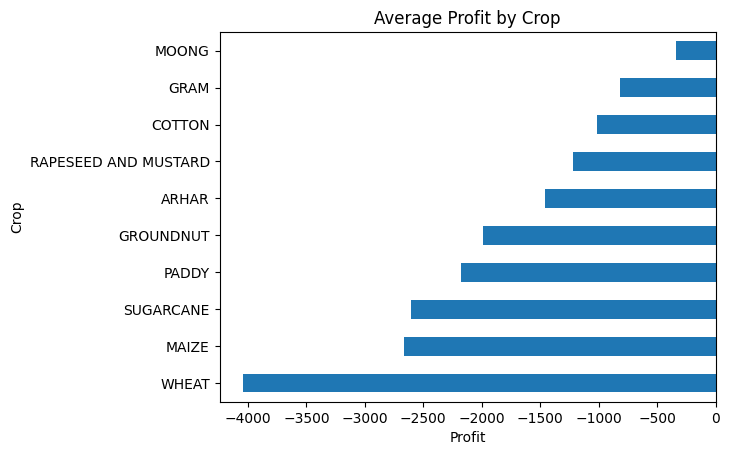

In [15]:
import matplotlib.pyplot as plt

df.groupby('Crop')['Profit'].mean().sort_values().plot(kind='barh')
plt.title("Average Profit by Crop")
plt.xlabel("Profit")
plt.show()

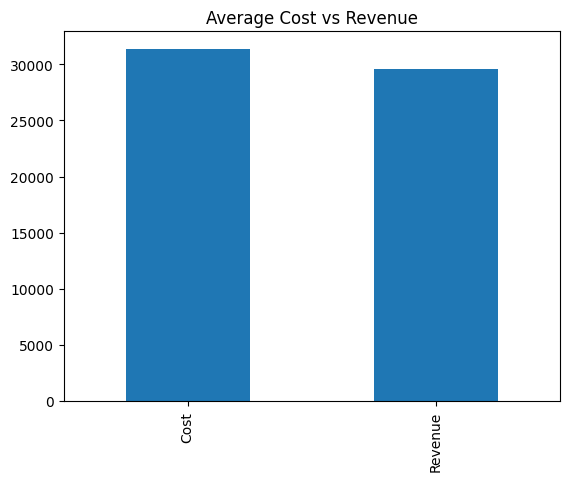

In [16]:
df[['Cost', 'Revenue']].mean().plot(kind='bar')
plt.title("Average Cost vs Revenue")
plt.show()

In [18]:
df.to_csv('./data/cleaned_data.csv', index=False)